# B vs Uniform Coverage (Grouped by `ij_damping`)

This notebook reads `results/metrics_*.json` (new schema) and plots `B_prefix` vs uniform coverage with one line per damping value.

In [12]:
from pathlib import Path
import json
import re

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")
JSON_GLOB = "metrics_*fitted*.json"

# Optional filters (set to None to disable)
FILTER_SEED = None
FILTER_B = 200

In [13]:
def _parse_alpha_key(alpha_key: str, fallback=None):
    m = re.match(r"alpha_(.+)", str(alpha_key))
    if not m:
        return fallback
    return float(m.group(1).replace("p", "."))


def _parse_k_key(k_key: str, fallback=None):
    m = re.match(r"k_(\d+)", str(k_key))
    if not m:
        return fallback
    return int(m.group(1))


def collect_coverage(results_dir: Path, json_glob: str = "metrics_*.json") -> pd.DataFrame:
    rows = []
    for path in sorted(results_dir.glob(json_glob)):
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        boot = data.get("bootstrap", {})
        run_seed = data.get("train_cfg_attn", {}).get("seed")
        B = boot.get("B")
        ij_damping = boot.get("ij_damping")

        coverage = data.get("coverage_by_alpha_k", {})
        for alpha_key, alpha_block in coverage.items():
            for k_key, k_block in alpha_block.items():
                alpha_val = k_block.get("alpha", _parse_alpha_key(alpha_key))
                k_val = k_block.get("k", _parse_k_key(k_key))

                for split in ("train", "test"):
                    split_block = k_block.get(split, {})
                    for target in ("raw_scores", "individual_spillover"):
                        by_prefix = split_block.get(target, {}).get("by_prefix", {})
                        for prefix_key, entry in by_prefix.items():
                            pointwise = entry.get("pointwise", {})
                            uniform = entry.get("uniform", {})
                            rows.append(
                                {
                                    "file": path.name,
                                    "seed": run_seed,
                                    "B": B,
                                    "ij_damping": ij_damping,
                                    "split": split,
                                    "target": target,
                                    "alpha": alpha_val,
                                    "k": k_val,
                                    "B_prefix": entry.get("B_prefix", prefix_key),
                                    "pointwise_all_covered": pointwise.get("all_covered", entry.get("pointwise_all_covered")),
                                    "pointwise_fraction_covered": pointwise.get("fraction_covered", entry.get("pointwise_fraction_covered")),
                                    "uniform_all_covered": uniform.get("all_covered", entry.get("uniform_all_covered")),
                                    "uniform_fraction_covered": uniform.get("fraction_covered", entry.get("uniform_fraction_covered")),
                                }
                            )

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    for col in [
        "seed", "B", "ij_damping", "alpha", "k", "B_prefix",
        "pointwise_all_covered", "pointwise_fraction_covered",
        "uniform_all_covered", "uniform_fraction_covered",
    ]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


raw_df = collect_coverage(RESULTS_DIR, JSON_GLOB)
if raw_df.empty:
    raise RuntimeError("No parsed rows found in results JSON files.")

df = raw_df.copy()
if FILTER_SEED is not None:
    df = df[df["seed"] == FILTER_SEED]
if FILTER_B is not None:
    df = df[df["B"] == FILTER_B]

agg = (
    df.groupby(["split", "target", "alpha", "k", "ij_damping", "B_prefix"], as_index=False)
    .agg(
        n_files=("file", "nunique"),
        pointwise_all_covered_mean=("pointwise_all_covered", "mean"),
        pointwise_fraction_covered_mean=("pointwise_fraction_covered", "mean"),
        uniform_all_covered_mean=("uniform_all_covered", "mean"),
        uniform_fraction_covered_mean=("uniform_fraction_covered", "mean"),
    )
    .sort_values(["split", "target", "alpha", "k", "ij_damping", "B_prefix"])
)

print("raw rows:", len(raw_df))
print("rows after filters:", len(df))
print("aggregated rows:", len(agg))
print("targets:", sorted(agg["target"].dropna().unique()))
print("damping values:", sorted(agg["ij_damping"].dropna().unique()))
agg.head(20)

raw rows: 10320
rows after filters: 10320
aggregated rows: 80
targets: ['individual_spillover', 'raw_scores']
damping values: [np.float64(0.0006)]


,split,target,alpha,k,ij_damping,B_prefix,n_files,pointwise_all_covered_mean,pointwise_fraction_covered_mean,uniform_all_covered_mean,uniform_fraction_covered_mean
0,test,individual_spillover,0.05,20,0.0006,20,129,0.147287,0.992287,0.992248,0.999992
1,test,individual_spillover,0.05,20,0.0006,40,129,0.279070,0.995288,1.000000,1.000000
2,test,individual_spillover,0.05,20,0.0006,60,129,0.356589,0.996563,1.000000,1.000000
3,test,individual_spillover,0.05,20,0.0006,80,129,0.379845,0.996952,1.000000,1.000000
4,test,individual_spillover,0.05,20,0.0006,100,129,0.403101,0.997139,1.000000,1.000000
5,test,individual_spillover,0.05,20,0.0006,120,129,0.426357,0.997504,1.000000,1.000000
6,test,individual_spillover,0.05,20,0.0006,140,129,0.480620,0.997722,1.000000,1.000000
7,test,individual_spillover,0.05,20,0.0006,160,129,0.465116,0.997714,1.000000,1.000000
8,test,individual_spillover,0.05,20,0.0006,180,129,0.527132,0.997947,1.000000,1.000000
9,test,individual_spillover,0.05,20,0.0006,200,129,0.534884,0.997924,1.000000,1.000000


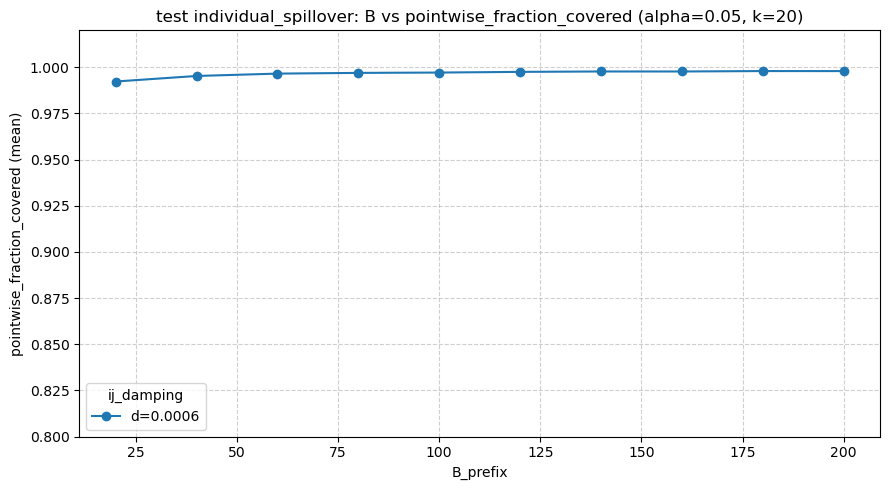

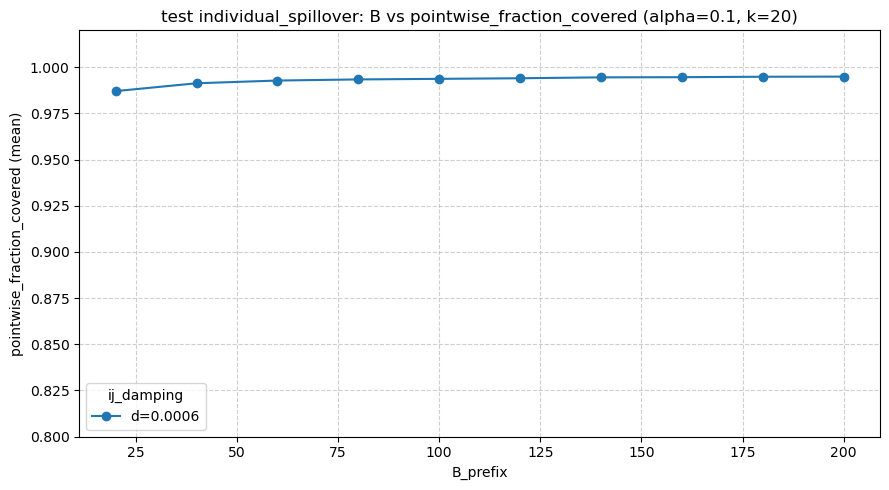

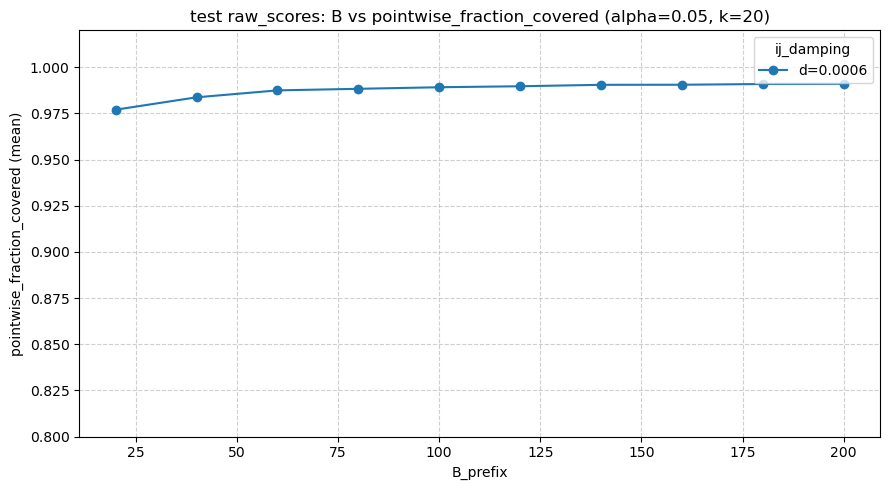

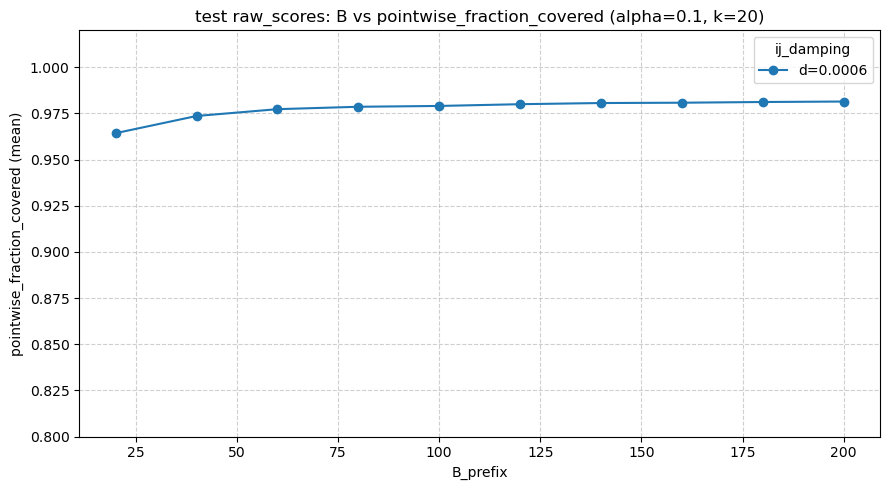

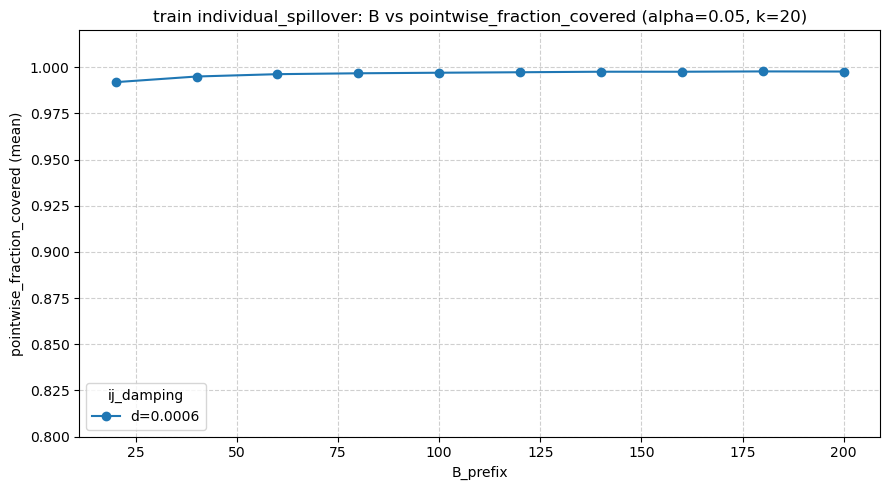

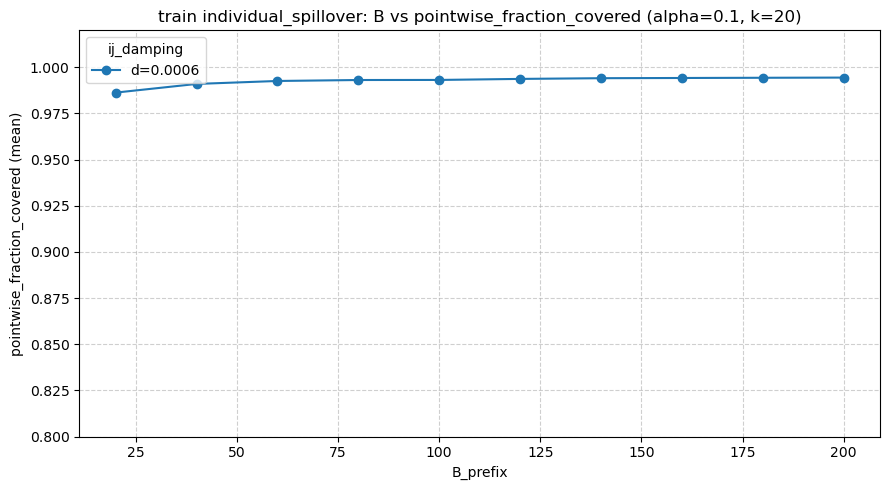

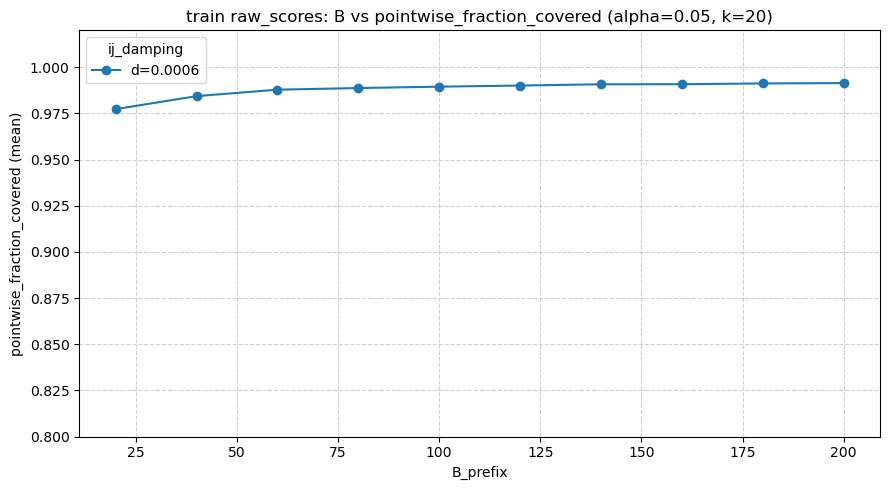

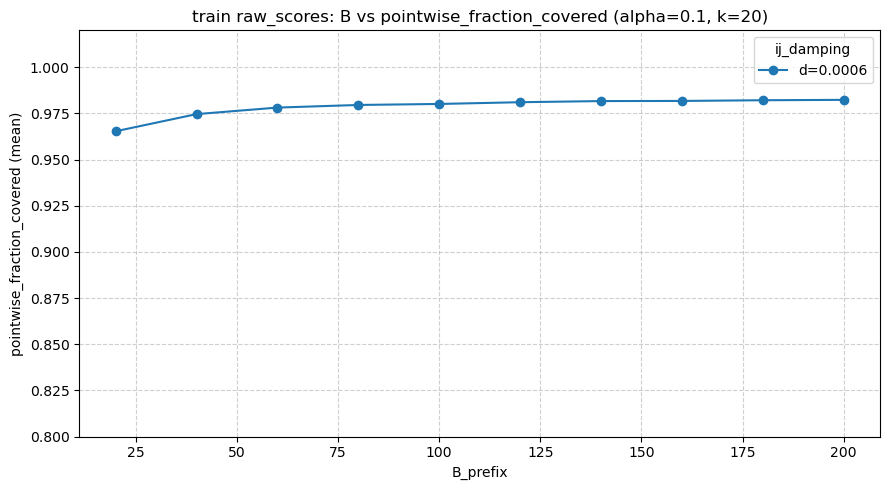

In [17]:
# Plot pointwise_fraction_covered separately for each split, target, alpha, and k.
for split_val in sorted(agg["split"].dropna().unique()):
    for target_val in sorted(agg["target"].dropna().unique()):
        for alpha_val in sorted(agg["alpha"].dropna().unique()):
            for k_val in sorted(agg["k"].dropna().unique()):
                sub = agg[
                    (agg["split"] == split_val) &
                    (agg["target"] == target_val) &
                    (agg["alpha"] == alpha_val) &
                    (agg["k"] == k_val)
                ]
                if sub.empty:
                    continue

                fig, ax = plt.subplots(figsize=(9, 5))
                for d_val in sorted(sub["ij_damping"].dropna().unique()):
                    line_df = sub[sub["ij_damping"] == d_val].sort_values("B_prefix")
                    ax.plot(
                        line_df["B_prefix"],
                        line_df["pointwise_fraction_covered_mean"],
                        marker="o",
                        label=f"d={d_val:g}",
                    )

                ax.set_xlabel("B_prefix")
                ax.set_ylabel("pointwise_fraction_covered (mean)")
                ax.set_ylim(0.8, 1.02)
                ax.set_title(
                    f"{split_val} {target_val}: B vs pointwise_fraction_covered "
                    f"(alpha={alpha_val}, k={int(k_val)})"
                )
                ax.grid(True, linestyle="--", alpha=0.6)
                ax.legend(title="ij_damping", ncol=2)
                plt.tight_layout()
                plt.show()

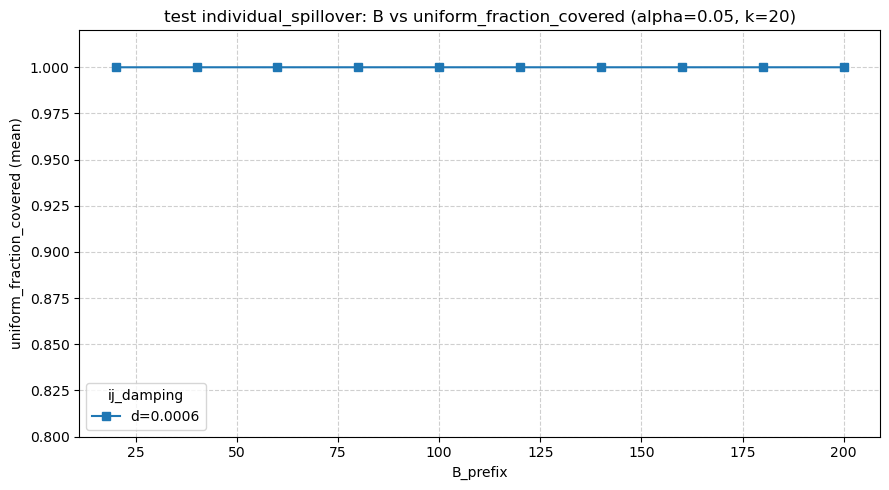

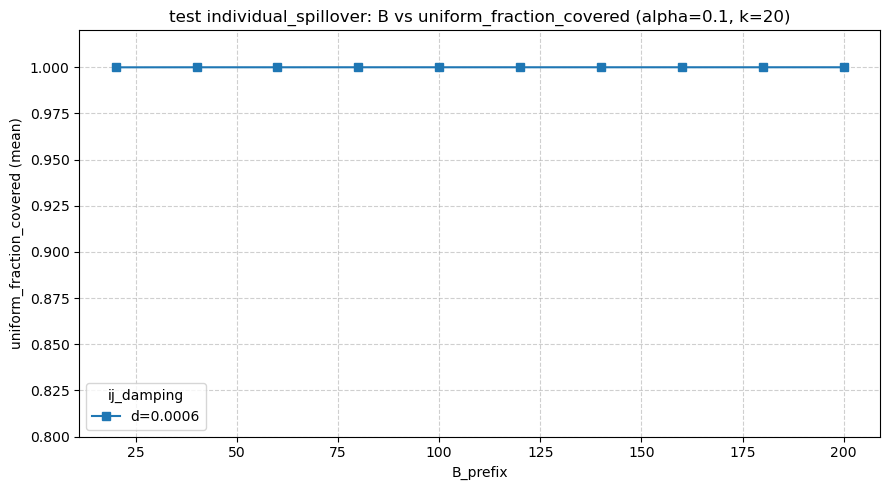

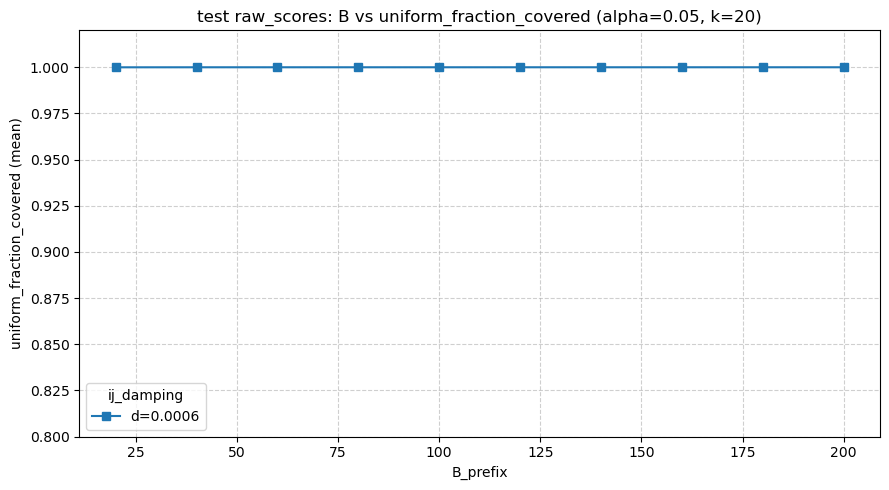

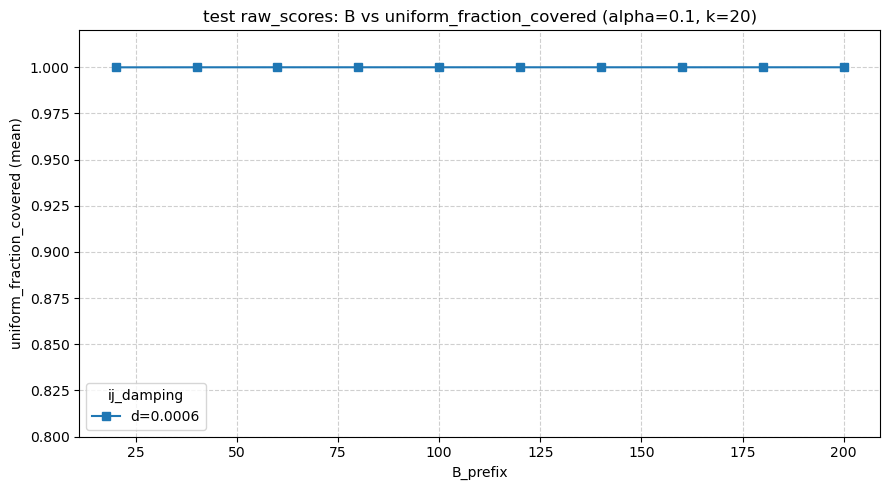

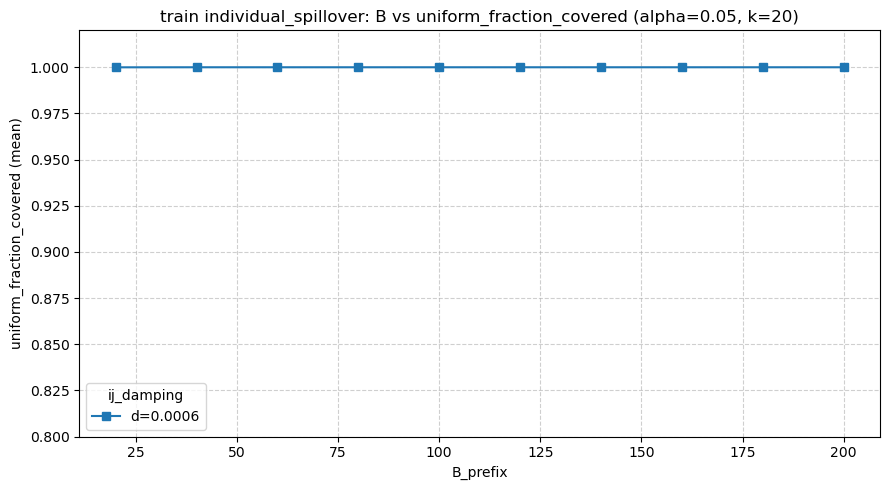

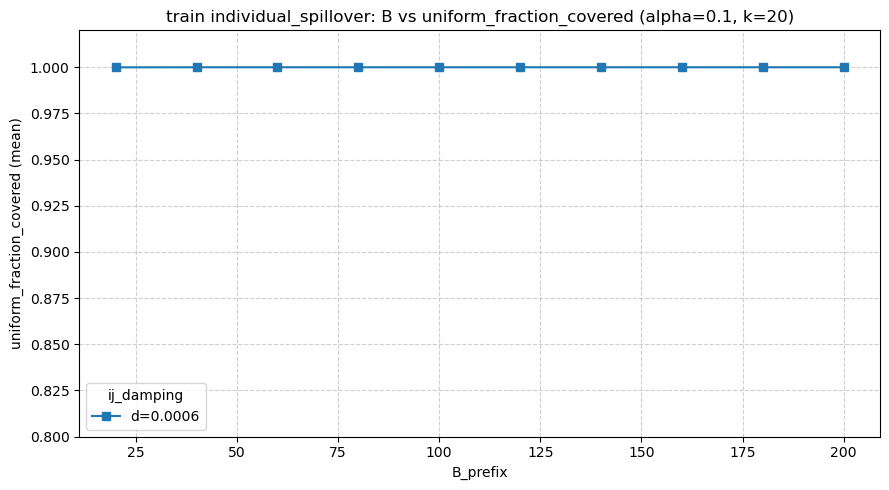

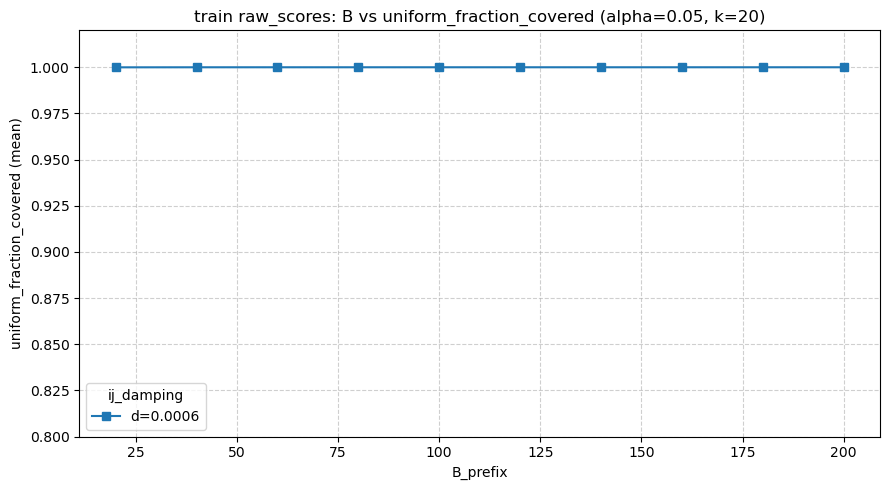

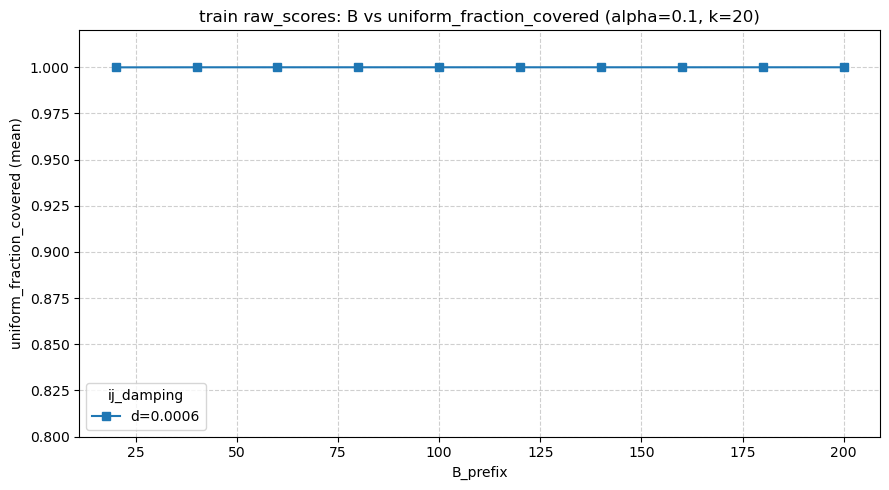

In [16]:
# Plot uniform_fraction_covered separately for each split, target, alpha, and k.
for split_val in sorted(agg["split"].dropna().unique()):
    for target_val in sorted(agg["target"].dropna().unique()):
        for alpha_val in sorted(agg["alpha"].dropna().unique()):
            for k_val in sorted(agg["k"].dropna().unique()):
                sub = agg[
                    (agg["split"] == split_val) &
                    (agg["target"] == target_val) &
                    (agg["alpha"] == alpha_val) &
                    (agg["k"] == k_val)
                ]
                if sub.empty:
                    continue

                fig, ax = plt.subplots(figsize=(9, 5))
                for d_val in sorted(sub["ij_damping"].dropna().unique()):
                    line_df = sub[sub["ij_damping"] == d_val].sort_values("B_prefix")
                    ax.plot(
                        line_df["B_prefix"],
                        line_df["uniform_fraction_covered_mean"],
                        marker="s",
                        label=f"d={d_val:g}",
                    )

                ax.set_xlabel("B_prefix")
                ax.set_ylabel("uniform_fraction_covered (mean)")
                ax.set_ylim(0.8, 1.02)
                ax.set_title(
                    f"{split_val} {target_val}: B vs uniform_fraction_covered "
                    f"(alpha={alpha_val}, k={int(k_val)})"
                )
                ax.grid(True, linestyle="--", alpha=0.6)
                ax.legend(title="ij_damping", ncol=2)
                plt.tight_layout()
                plt.show()